Clone git repo

In [32]:
!git clone https://github.com/KaizokuOu56/movingMirror.git

Cloning into 'movingMirror'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 175 (delta 38), reused 42 (delta 12), pack-reused 93 (from 1)
Receiving objects: 100% (175/175), 175.37 MiB | 23.82 MiB/s, done.
Resolving deltas: 100% (66/66), done.


Import drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
save_dir = "/content/drive/MyDrive/movingMirror/experimental_data/trial7"
os.makedirs(save_dir, exist_ok=True)

Hyperparameters

In [3]:
import numpy as np
N = 50   # grid size
num_samples = 25000
epochs = 10
f_scale = np.exp(20)
param_low = 1.0
param_high = 5.0

In [4]:
# the x axis ie time
t = np.linspace(0, 2, N, endpoint=False, dtype = np.float64)

Path parameters (for testing)

In [5]:
rng = np.random.default_rng()

A = rng.uniform(low = param_low, high = param_high)
B = rng.uniform(low = param_low, high = param_high)
kappa = rng.uniform(low = param_low, high = param_high)
print(kappa)

2.1366206131939913


Path parameters generation

In [6]:
def generate_path_parameters():
    A_ = rng.uniform(low = param_low, high = param_high)
    # B_ = rng.uniform(low = param_low, high = param_high)
    B_ = 0 # set to 0 for now
    kappa_ = rng.uniform(low = param_low, high = param_high)
    return A_, B_, kappa_

Create trajectories

In [7]:
def generate_trajectories(t):
    """
    Returns f ∈ R
    """
    A_, B_, kappa_ = generate_path_parameters()
    f = -t - A_ * np.exp(-2 * kappa_ * t) + B_   #argument is negative of original so log is valid
    # print(f"A: {A_}, B: {B_}, Kappa: {kappa_}")
    return f

In [22]:
def generate_trajectory_specific(t, A_, B_, kappa_):
  f = -t - A_ * np.exp(-2 * kappa_ * t) + B_
  return f

Test Plot

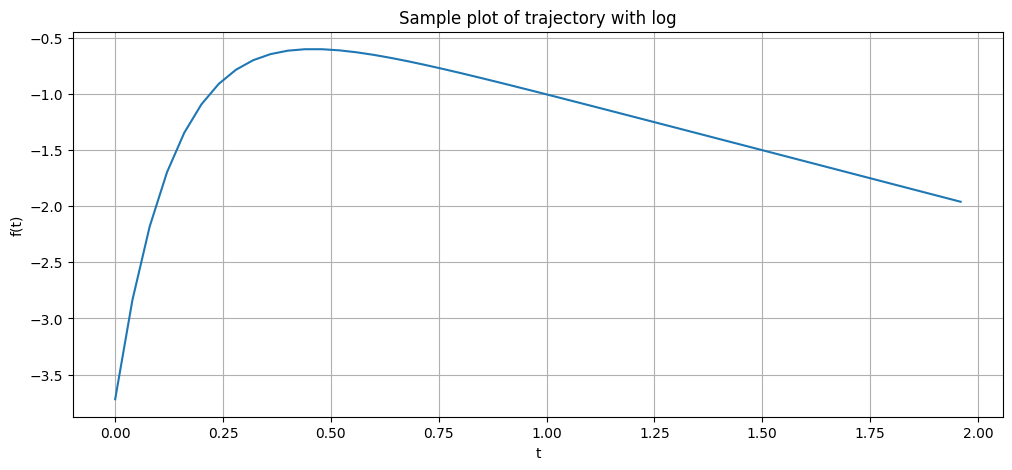

In [8]:
import matplotlib.pyplot as plt
test_f = generate_trajectories(t)

plt.figure(figsize=(12, 5))
plt.plot(t, test_f, label='WOag')
plt.title(f'Sample plot of trajectory with log')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid(True)
plt.show()

Generate Beta matrix

*   B = 0, easier for dataset generation
*   adding 1 to make purely positive (disregard)
*   multiplying by 10 so learning improves



In [9]:
from scipy.special import gamma
def generate_beta_matrix(A_, B_, kappa_, N=N):
  Y = np.zeros((N, N), dtype=np.complex128)
  D = (1/kappa_)*np.log(A_)
  for i in range(1, N+1):
    for j in range(1, N+1):
      Y[i-1, j-1] = 10*(1j/(2*np.pi*i*j))*np.exp(-np.pi*1j/(2*kappa_))*np.exp(-1j*i*D)*np.exp(-(1j*i/kappa_)*np.log(j))*gamma(1+(1j*i)/kappa_)
  return Y

Generate Alpha matrix

In [10]:
def generate_alpha_matrix(A_, B_, kappa_, N=N):
  Y = np.zeros((N, N), dtype=np.complex128)
  D = (1/kappa_)*np.log(A_)
  for i in range(1, N+1):
    for j in range(1, N+1):
      Y[i-1, j-1] = -10*(1j/(2*np.pi*i*j))*np.exp(np.pi*1j/(2*kappa_))*np.exp(-1j*i*D)*np.exp(-(1j*i/kappa_)*np.log(j))*gamma(1+(1j*i)/kappa_)
  return Y

Alpha/Beta matrix for testing (including B)

In [11]:
def generate_aOrb_matrix(choice, A_, B_, kappa_, N=N):
  Y = np.zeros((N, N), dtype=np.complex128)
  D = (1/kappa_)*np.log(A_) - B_

  if choice == "alpha":
    for i in range(1, N+1):
      for j in range(1, N+1):
        Y[i-1, j-1] = -(1j/(2*np.pi*i*j))*np.exp(np.pi*1j/(2*kappa_))*np.exp(-1j*i*D)*np.exp(1j*j*B_)*np.exp(-(1j*i/kappa_)*np.log(j))*gamma(1+(1j*i)/kappa_)

  elif choice == "beta":
    for i in range(1, N+1):
      for j in range(1, N+1):
        Y[i-1, j-1] = (1j/(2*np.pi*i*j))*np.exp(-np.pi*1j/(2*kappa_))*np.exp(-1j*i*D)*np.exp(-1j*j*B_)*np.exp(-(1j*i/kappa_)*np.log(j))*gamma(1+(1j*i)/kappa_)

  else:
    raise ValueError("Only alpha or beta allowed")

  return Y

For testing, now generate 15625 alpha and beta matrices (25 different values for A, B and ĸ), separate into real and imaginary, then plot mean and deviations separately.


*   Plotted the data of the bottom left side (N/2, N/2) size
*   Alpha seems basically 0, Beta has good variation
*   Consider multiplying Alpha to make it of larger magnitude



In [ ]:
from tqdm.notebook import tqdm

num_data = 10000

test_Alphas = np.zeros((num_data, N, N), dtype=np.complex128)
test_Betas = np.zeros((num_data, N, N), dtype=np.complex128)
means_alpha_real = np.zeros((N, N))
means_alpha_imag = np.zeros((N, N))
means_beta_real = np.zeros((N, N))
means_beta_imag = np.zeros((N, N))
dev_alpha_real = np.zeros((N, N))
dev_alpha_imag = np.zeros((N, N))
dev_beta_real = np.zeros((N, N))
dev_beta_imag = np.zeros((N,N))

for i in tqdm(range(num_data), desc = "Generating matrices"):
  A_, B_, kappa_ = generate_path_parameters()
  test_Alphas[idx] = generate_aOrb_matrix("alpha", A_, B_, kappa_)
  test_Betas[idx] = generate_aOrb_matrix("beta", A_, B_, kappa_)
    # print(f"j = {j}")
    # print(f"i = {i}")

In [ ]:
#how much size
def pretty_bytes(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024

print(pretty_bytes(test_Alphas.nbytes))

Save generated data

In [ ]:
# Create the target directory
sample_save_dir = os.path.join(save_dir, "sample_alphasNdBetas")
os.makedirs(sample_save_dir, exist_ok=True)

# Define file paths
alphas_file = os.path.join(sample_save_dir, "test_Alphas.npy")
betas_file = os.path.join(sample_save_dir, "test_Betas.npy")

# Save the arrays
np.save(alphas_file, test_Alphas)
np.save(betas_file, test_Betas)

print(f"test_Alphas saved to: {alphas_file}")
print(f"test_Betas saved to: {betas_file}")

test_Alphas saved to: /content/drive/MyDrive/movingMirror/experimental_data/trial7/sample_alphasNdBetas/test_Alphas.npy
test_Betas saved to: /content/drive/MyDrive/movingMirror/experimental_data/trial7/sample_alphasNdBetas/test_Betas.npy


Load saved data

In [ ]:
# Define the directory where the files were saved
sample_save_dir = os.path.join(save_dir, "sample_alphasNdBetas")

# Define file paths
alphas_file = os.path.join(sample_save_dir, "test_Alphas.npy")
betas_file = os.path.join(sample_save_dir, "test_Betas.npy")

# Load the arrays back into new variables
loaded_test_Alphas = np.load(alphas_file)
loaded_test_Betas = np.load(betas_file)

print("Loaded test_Alphas shape:", loaded_test_Alphas.shape)
print("Loaded test_Betas shape:", loaded_test_Betas.shape)
print("Data loaded successfully!")

Loaded test_Alphas shape: (10000, 50, 50)
Loaded test_Betas shape: (10000, 50, 50)
Data loaded successfully!


In [ ]:
test_Alphas = loaded_test_Alphas
test_Betas = loaded_test_Betas
means_alpha_real = test_Alphas.real.mean(axis=0)
means_alpha_imag = test_Alphas.imag.mean(axis=0)
means_beta_real  = test_Betas.real.mean(axis=0)
means_beta_imag  = test_Betas.imag.mean(axis=0)

dev_alpha_real = test_Alphas.real.std(axis=0)
dev_alpha_imag = test_Alphas.imag.std(axis=0)
dev_beta_real  = test_Betas.real.std(axis=0)
dev_beta_imag  = test_Betas.imag.std(axis=0)

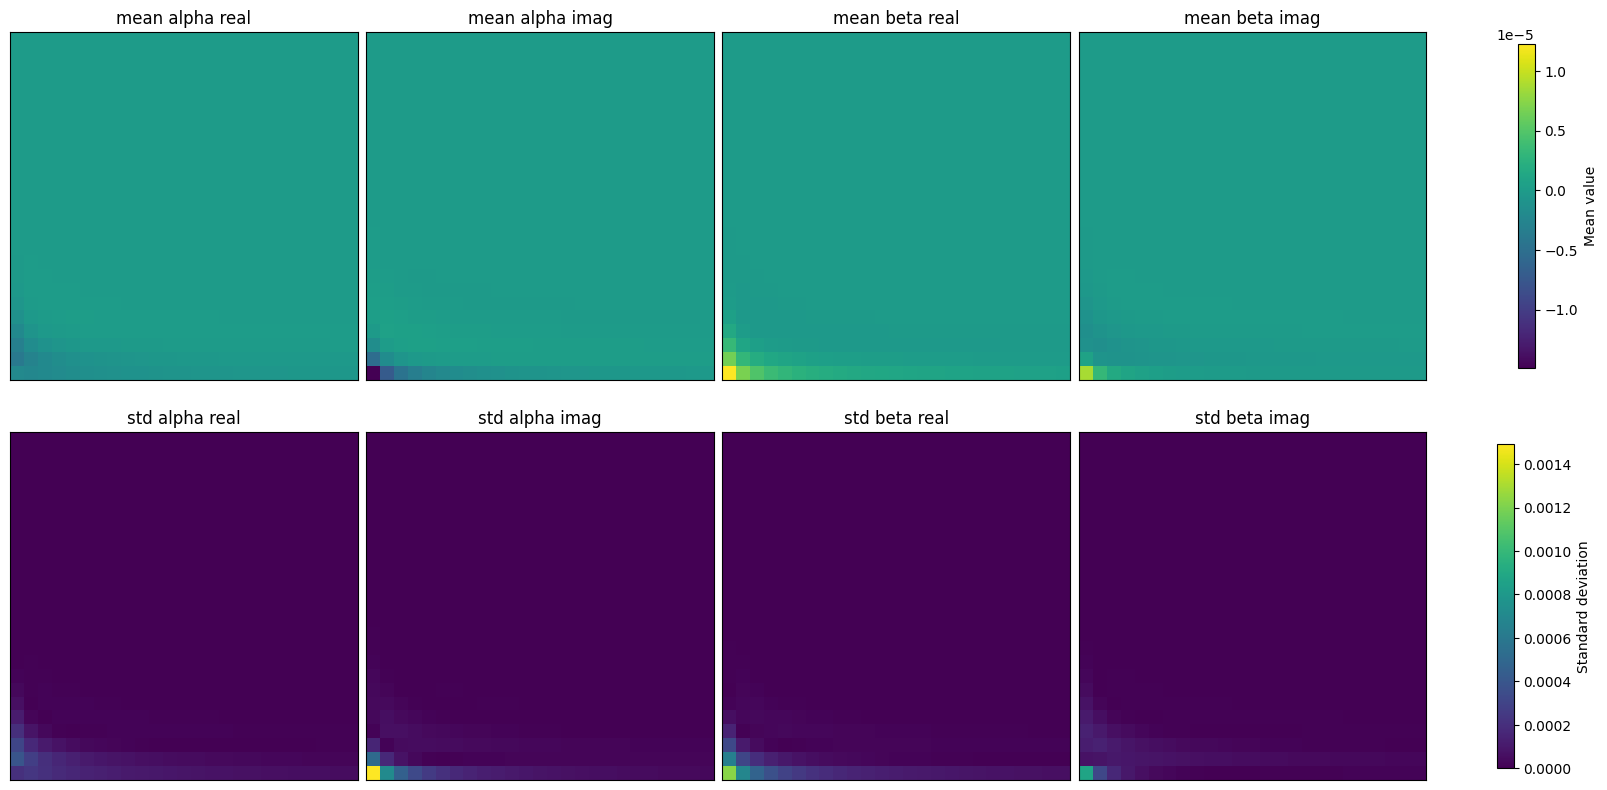

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

mean_mats = [
    means_alpha_real,
    means_alpha_imag,
    means_beta_real,
    means_beta_imag
]

std_mats = [
    dev_alpha_real,
    dev_alpha_imag,
    dev_beta_real,
    dev_beta_imag
]

mean_titles = [
    "mean alpha real",
    "mean alpha imag",
    "mean beta real",
    "mean beta imag"
]

std_titles = [
    "std alpha real",
    "std alpha imag",
    "std beta real",
    "std beta imag"
]

# --- compute grouped color scales ---
mean_vmin = min(np.nanmin(M) for M in mean_mats)
mean_vmax = max(np.nanmax(M) for M in mean_mats)

std_vmin = min(np.nanmin(M) for M in std_mats)
std_vmax = max(np.nanmax(M) for M in std_mats)

# --- plot means (top row) ---
for ax, M, title in zip(axes[0], mean_mats, mean_titles):
    im_mean = ax.imshow(
        M[:N//2, :N//2],
        cmap="viridis",
        origin="lower",
        vmin=mean_vmin,
        vmax=mean_vmax
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# --- plot stds (bottom row) ---
for ax, M, title in zip(axes[1], std_mats, std_titles):
    im_std = ax.imshow(
        M[:N//2, :N//2],
        cmap="viridis",
        origin="lower",
        vmin=std_vmin,
        vmax=std_vmax
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# --- two separate colorbars ---
cbar_mean = fig.colorbar(
    im_mean, ax=axes[0], shrink=0.85, location="right"
)
cbar_mean.set_label("Mean value")

cbar_std = fig.colorbar(
    im_std, ax=axes[1], shrink=0.85, location="right"
)
cbar_std.set_label("Standard deviation")

plt.show()

save_path = os.path.join(save_dir, "samples_test_data.png")
fig.savefig(save_path, dpi=600, bbox_inches="tight")

In [ ]:
import plotly.graph_objects as go

# define grid
x = t
y = t
X, Y = np.meshgrid(x, y)

# define function
Z = means_alpha_real   # your function here

# create surface plot
fig = go.Figure(
    data=go.Surface(x=X, y=Y, z=Z, colorscale="Viridis")
)

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="f(x, y)"
    ),
    title="3D surface plot"
)

fig.show()


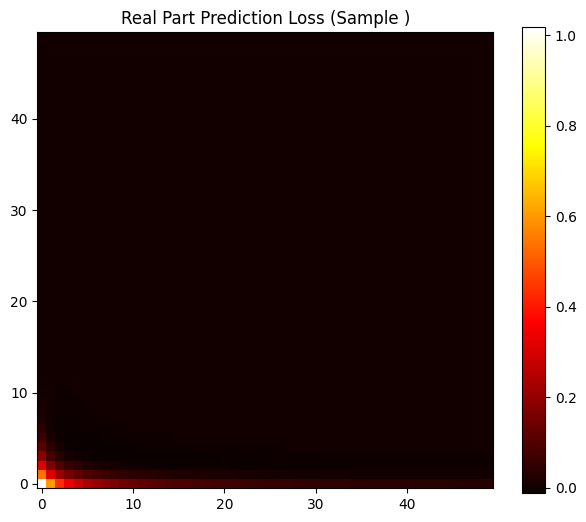

In [ ]:
tempA, tempB, tempk = generate_path_parameters()
tempY = generate_beta_matrix(tempA, tempB, tempk)
tempY = tempY.real
# tempY = tempY / np.linalg.norm(tempY)

# You can visualize these matrices, for example, using imshow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(tempY.real, cmap='hot', origin='lower')
plt.title(f'Real Part Prediction Loss (Sample )')
plt.colorbar()

# plt.subplot(1, 2, 2)
# plt.imshow(loaded_imag_loss.squeeze(), cmap='hot', origin='lower')
# plt.title(f'Imaginary Part Prediction Loss (Sample {random_sample_idx})')
# plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go

# define grid
x = t
y = t
X, Y = np.meshgrid(x, y)

# define function
Z = tempY   # your function here

# create surface plot
fig = go.Figure(
    data=go.Surface(x=X, y=Y, z=Z, colorscale="Viridis")
)

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="f(x, y)"
    ),
    title="3D surface plot"
)

fig.show()


In [ ]:
print(tempY.real.max())
print(tempY.real.min())

0.12494108156369929
-3.6462752839034635e-06


Dataset generation

In [ ]:
X = np.zeros((num_samples, N, N))
Betas = np.zeros((num_samples, N, N), dtype=np.complex128)
Alphas = np.zeros((num_samples, N, N), dtype=np.complex128)

for i in tqdm(range(num_samples), desc = "generation loop"):
    x = generate_trajectories(t)
    A_, B_, kappa_ = generate_path_parameters()
    beta = generate_beta_matrix(A_, B_, kappa_)
    alpha = generate_alpha_matrix(A_, B_, kappa_)

    X[i] = np.repeat(x[np.newaxis, :], N, axis=0)
    Betas[i] = beta
    Alphas[i] = alpha

Save data

In [ ]:
# Create the target directory
model_save_dir = "/content/drive/MyDrive/movingMirror/models/davies"
os.makedirs(model_save_dir, exist_ok=True)
data_save_dir = os.path.join(model_save_dir, "model_data")
os.makedirs(data_save_dir, exist_ok=True)

# Define file paths
x_file = os.path.join(data_save_dir, "traj.npy")
alphas_file = os.path.join(data_save_dir, "Alphas.npy")
betas_file = os.path.join(data_save_dir, "Betas.npy")

# Save the arrays
np.save(x_file, X)
np.save(alphas_file, Alphas)
np.save(betas_file, Betas)

print(f"Alphas saved to: {alphas_file}")

Alphas saved to: /content/drive/MyDrive/movingMirror/models/davies/model_data/Alphas.npy


Load saved data

In [13]:
# Define the target directory
model_save_dir = "/content/drive/MyDrive/movingMirror/models/davies"
os.makedirs(model_save_dir, exist_ok=True)
data_save_dir = os.path.join(model_save_dir, "model_data")
os.makedirs(data_save_dir, exist_ok=True)

# Define file paths
x_file = os.path.join(data_save_dir, "traj.npy")
alphas_file = os.path.join(data_save_dir, "Alphas.npy")
betas_file = os.path.join(data_save_dir, "Betas.npy")

# Load the arrays back into new variables
loaded_X = np.load(x_file)
loaded_Alphas = np.load(alphas_file)
loaded_Betas = np.load(betas_file)

print("Data loaded successfully!")
#40 seconds to load

Data loaded successfully!


In [14]:
X = loaded_X
Betas = loaded_Betas
Alphas = loaded_Alphas

In [15]:
import torch
from torch.utils.data import Dataset

class DaviesDataset(Dataset):
    def __init__(self, X, Alphas, Betas):
        self.x = torch.tensor(X, dtype=torch.float32)        # (num_samples, N, N)
        self.alpha_r = torch.tensor(Alphas.real, dtype=torch.float32)      # (num_samples, N, N)
        self.alpha_i = torch.tensor(Alphas.imag, dtype=torch.float32)      # (num_samples, N, N)
        self.beta_r = torch.tensor(Betas.real, dtype=torch.float32)      # (num_samples, N, N)
        self.beta_i = torch.tensor(Betas.imag, dtype=torch.float32)      # (num_samples, N, N)

        self.H = self.alpha_r.shape[1]
        self.W = self.alpha_r.shape[2]

        # precompute coordinate grid
        yy, xx = torch.meshgrid(
            torch.linspace(0, 1, self.H),
            torch.linspace(0, 1, self.W),
            indexing="ij"
        )
        self.coords = torch.stack([xx, yy])  # (2, H, W)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        x_chan = self.x[idx].unsqueeze(0)
        br_chan = self.beta_r[idx].unsqueeze(0)
        bi_chan = self.beta_i[idx].unsqueeze(0)
        # --- concatenate all ---
        inp = torch.cat([x_chan, br_chan, bi_chan, self.coords], dim=0)
        # (5, H, W)

        alpha_r = self.alpha_r[idx][None, :, :]        # (1, H, W)
        alpha_i = self.alpha_i[idx][None, :, :]        # (1, H, W)

        return inp, alpha_r, alpha_i

In [16]:
!pip install neuraloperator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.1 MB/s eta 0:00:00


In [17]:
from neuralop.models import FNO

def make_fnoDavies():
    return FNO(
        n_modes=(16, 16),
        hidden_channels=64,
        in_channels=5,    # x + (x,y) coords
        out_channels=1,
        n_layers=4
    )

model_real = make_fnoDavies()
model_imag = make_fnoDavies()

In [18]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_real.to(device)
model_imag.to(device)

dataset = DaviesDataset(X, Alphas, Betas)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

opt_real = torch.optim.Adam(model_real.parameters(), lr=1e-3)
opt_imag = torch.optim.Adam(model_imag.parameters(), lr=1e-3)

In [ ]:
losses = []

model_real.train()
model_imag.train()

for epoch in range(5):
    epoch_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch}", leave=False)

    for x, y_r, y_i in pbar:
        x   = x.to(device)
        y_r = y_r.to(device)
        y_i = y_i.to(device)

        # --- real ---
        pred_r = model_real(x)
        loss_r = F.mse_loss(pred_r, y_r)
        opt_real.zero_grad()
        loss_r.backward()
        opt_real.step()

        # --- imag ---
        pred_i = model_imag(x)
        loss_i = F.mse_loss(pred_i, y_i)
        opt_imag.zero_grad()
        loss_i.backward()
        opt_imag.step()

        loss = loss_r + loss_i
        epoch_loss += loss.item()

        pbar.set_postfix({
            "Re": f"{loss_r.item():.2e}",
            "Im": f"{loss_i.item():.2e}"
        })

    epoch_loss /= len(loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch} | Total loss = {epoch_loss:.3e}")

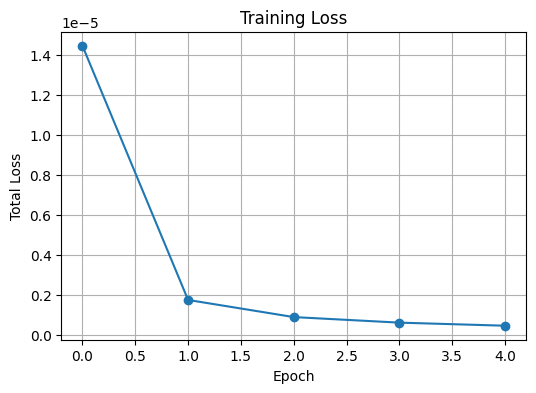

In [21]:
epochs_plotting = np.arange(len(losses))
plt.figure(figsize=(6,4))
plt.plot(epochs_plotting, losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

TESTING TIME (need to clean up code later)

In [27]:
test_A, test_B, test_kappa = generate_path_parameters()
test_Alphas = generate_alpha_matrix(test_A, test_B, test_kappa)
test_Betas = generate_beta_matrix(test_A, test_B, test_kappa)
test_x = generate_trajectory_specific(t, test_A, test_B, test_kappa)

test_x_2d = np.repeat(test_x[np.newaxis, :], N, axis=0)

x_tensor = torch.from_numpy(test_x_2d).float().unsqueeze(0).unsqueeze(0)

# Split Beta into Real and Imaginary (1, 1, 200, 200 each)
br = torch.from_numpy(test_Betas.real).float().unsqueeze(0).unsqueeze(0)
bi = torch.from_numpy(test_Betas.imag).float().unsqueeze(0).unsqueeze(0)

# 2. Create the Grid (must match training resolution)
H, W = test_Betas.shape
yy, xx = torch.meshgrid(torch.linspace(0, 1, H), torch.linspace(0, 1, W), indexing="ij")
coords = torch.stack([xx, yy]).unsqueeze(0) # Shape: (1, 2, 200, 200)

# 3. Concatenate into the 5-channel input
# Order must be same as training: [x, beta_r, beta_i, coord_x, coord_y]
test_input = torch.cat([x_tensor, br, bi, coords], dim=1)

# 4. Move to GPU if your model is on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_real.to(device)
model_imag.to(device)
test_input = test_input.to(device)

# 5. Run Inference
model_real.eval()
model_imag.eval()
with torch.no_grad():
    prediction_real = model_real(test_input)
    prediction_imag = model_imag(test_input)

### True vs. Predicted Alpha Heatmaps

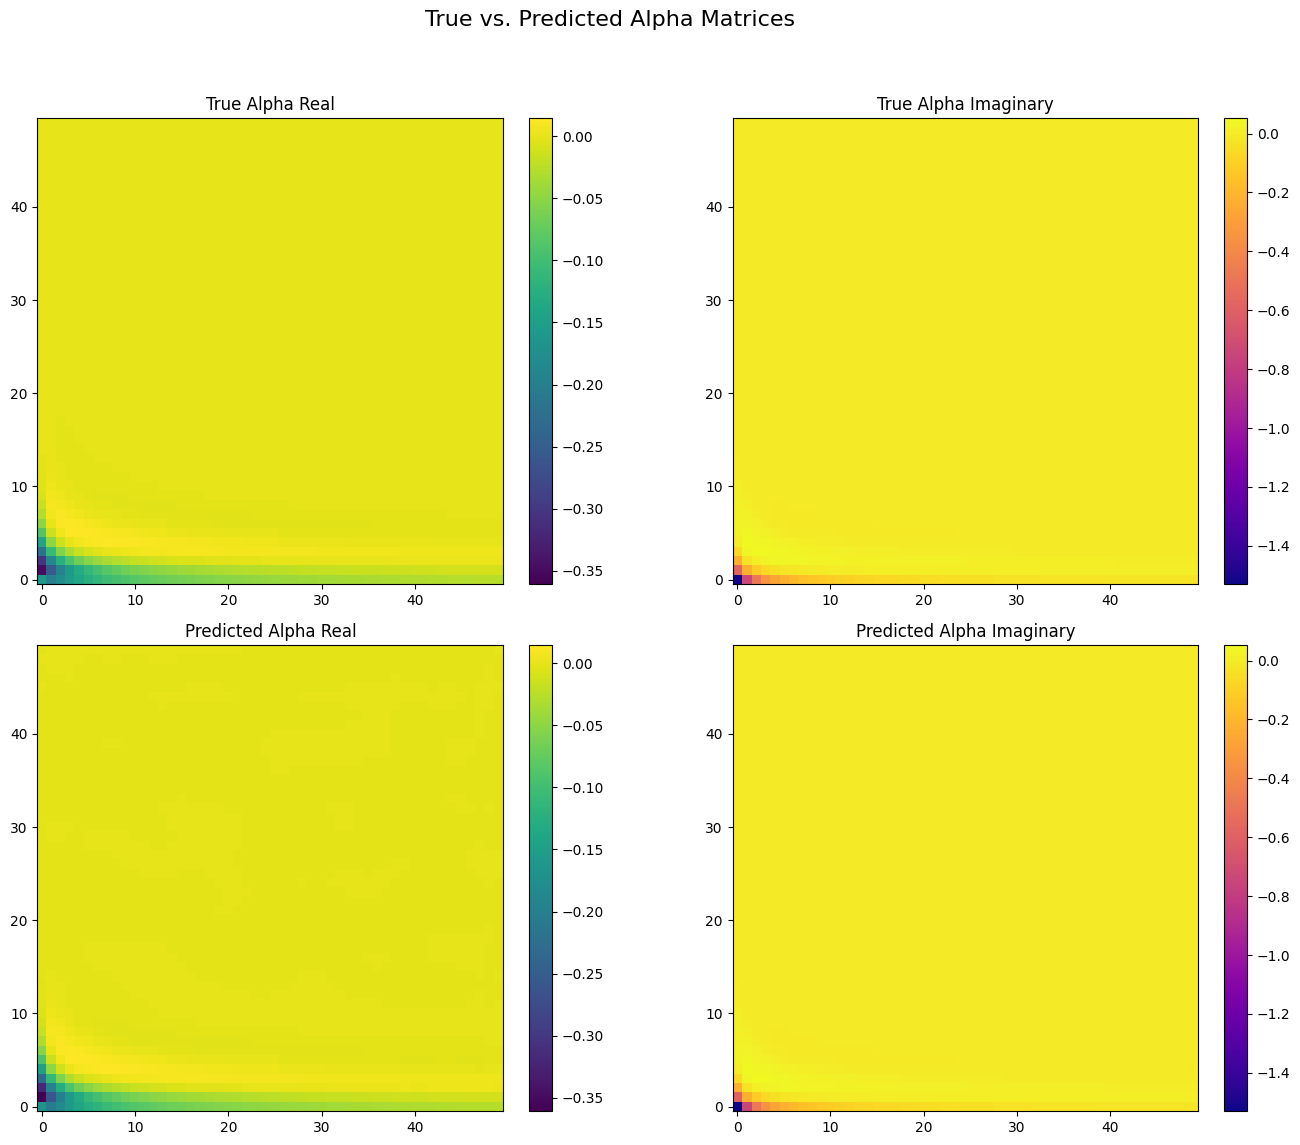

Comparison plot saved to: /content/drive/MyDrive/movingMirror/experimental_data/trial7/alpha_prediction_comparison.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure predictions are on CPU and converted to numpy
predicted_alpha_real_np = prediction_real.cpu().numpy().squeeze()
predicted_alpha_imag_np = prediction_imag.cpu().numpy().squeeze()

# Get true alpha values
true_alpha_real_np = test_Alphas.real
true_alpha_imag_np = test_Alphas.imag

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('True vs. Predicted Alpha Matrices', fontsize=16)

# Determine common color scale for real parts
real_min = min(np.min(true_alpha_real_np), np.min(predicted_alpha_real_np))
real_max = max(np.max(true_alpha_real_np), np.max(predicted_alpha_real_np))

# Determine common color scale for imaginary parts
imag_min = min(np.min(true_alpha_imag_np), np.min(predicted_alpha_imag_np))
imag_max = max(np.max(true_alpha_imag_np), np.max(predicted_alpha_imag_np))

# Plot True Alpha Real
im1 = axes[0, 0].imshow(true_alpha_real_np, cmap='viridis', origin='lower', vmin=real_min, vmax=real_max)
axes[0, 0].set_title('True Alpha Real')
fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

# Plot True Alpha Imaginary
im2 = axes[0, 1].imshow(true_alpha_imag_np, cmap='plasma', origin='lower', vmin=imag_min, vmax=imag_max)
axes[0, 1].set_title('True Alpha Imaginary')
fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Plot Predicted Alpha Real
im3 = axes[1, 0].imshow(predicted_alpha_real_np, cmap='viridis', origin='lower', vmin=real_min, vmax=real_max)
axes[1, 0].set_title('Predicted Alpha Real')
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Plot Predicted Alpha Imaginary
im4 = axes[1, 1].imshow(predicted_alpha_imag_np, cmap='plasma', origin='lower', vmin=imag_min, vmax=imag_max)
axes[1, 1].set_title('Predicted Alpha Imaginary')
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Save the figure
save_path_comparison = os.path.join(save_dir, "alpha_prediction_comparison.png")
fig.savefig(save_path_comparison, dpi=300, bbox_inches="tight")
print(f"Comparison plot saved to: {save_path_comparison}")

### Prediction Loss Heatmaps

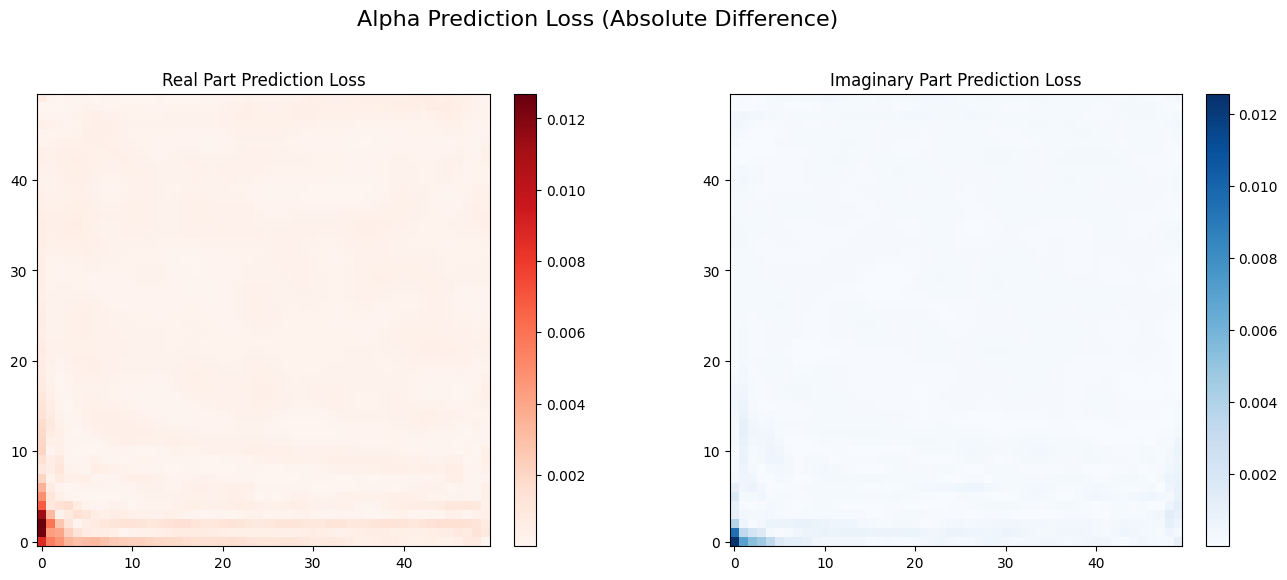

Prediction loss plot saved to: /content/drive/MyDrive/movingMirror/experimental_data/trial7/alpha_prediction_loss.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the absolute difference for real and imaginary parts
real_loss = np.abs(true_alpha_real_np - predicted_alpha_real_np)
imag_loss = np.abs(true_alpha_imag_np - predicted_alpha_imag_np)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Alpha Prediction Loss (Absolute Difference)', fontsize=16)

# Plot Real Part Loss
im_real_loss = axes[0].imshow(real_loss, cmap='Reds', origin='lower')
axes[0].set_title('Real Part Prediction Loss')
fig.colorbar(im_real_loss, ax=axes[0], fraction=0.046, pad=0.04)

# Plot Imaginary Part Loss
im_imag_loss = axes[1].imshow(imag_loss, cmap='Blues', origin='lower')
axes[1].set_title('Imaginary Part Prediction Loss')
fig.colorbar(im_imag_loss, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Save the figure
save_path_loss = os.path.join(save_dir, "alpha_prediction_loss.png")
fig.savefig(save_path_loss, dpi=300, bbox_inches="tight")
print(f"Prediction loss plot saved to: {save_path_loss}")

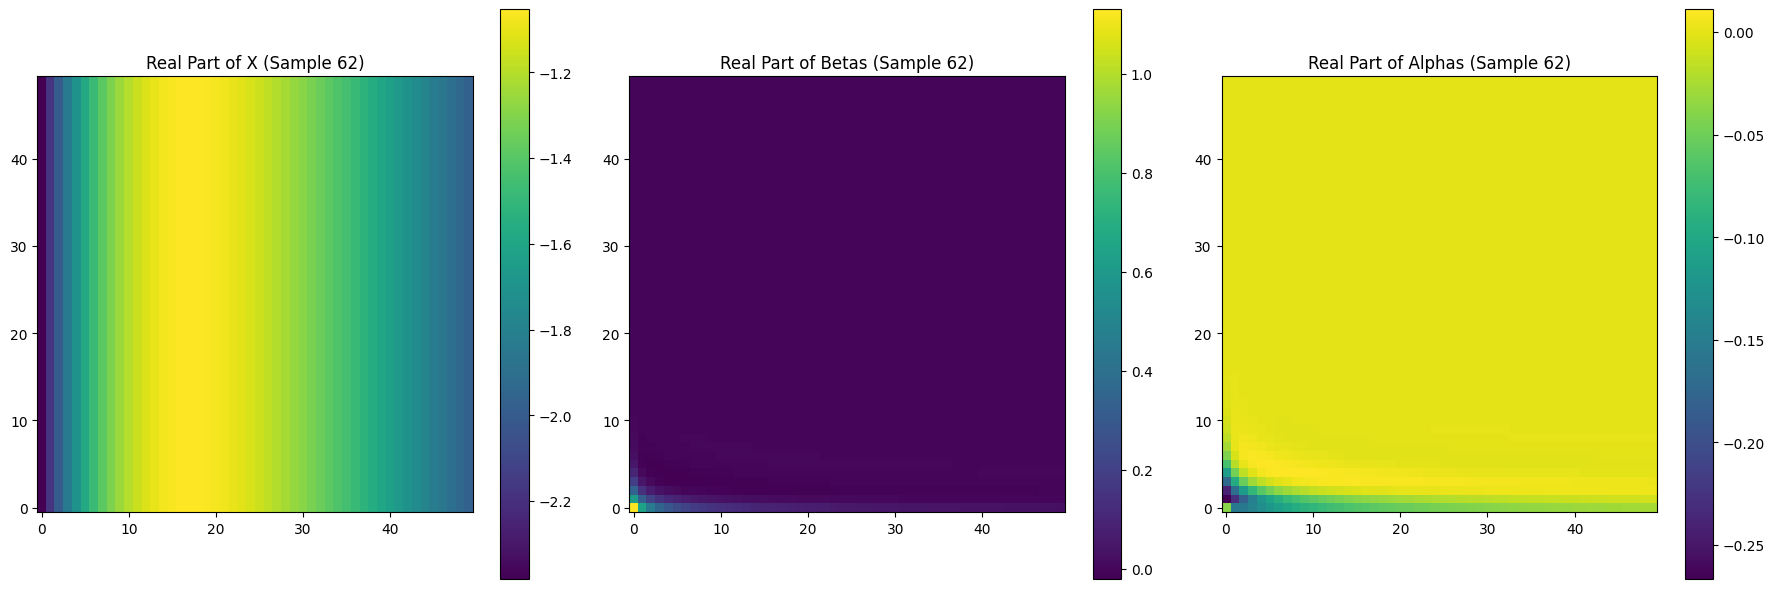

In [ ]:
import random

# Choose a random sample index
random_sample_idx = random.randint(0, 1000 - 1);

# Get the random samples
sample_X = X[random_sample_idx];
sample_Betas = Betas[random_sample_idx];
sample_Alphas = Alphas[random_sample_idx];

# Plotting the real parts of the matrices
plt.figure(figsize=(18, 6));

plt.subplot(1, 3, 1);
plt.imshow(sample_X, cmap='viridis', origin='lower');
plt.title(f'Real Part of X (Sample {random_sample_idx})');
plt.colorbar();

plt.subplot(1, 3, 2);
plt.imshow(sample_Betas.real, cmap='viridis', origin='lower');
plt.title(f'Real Part of Betas (Sample {random_sample_idx})');
plt.colorbar();

plt.subplot(1, 3, 3);
plt.imshow(sample_Alphas.real, cmap='viridis', origin='lower');
plt.title(f'Real Part of Alphas (Sample {random_sample_idx})');
plt.colorbar();

plt.tight_layout();
save_path = os.path.join(save_dir, "sample_alphaNdBeta.png");
plt.savefig(save_path, dpi=300, bbox_inches="tight");
plt.show();